In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Goal 1: Nyquist Sampling

### Section 5.3.1

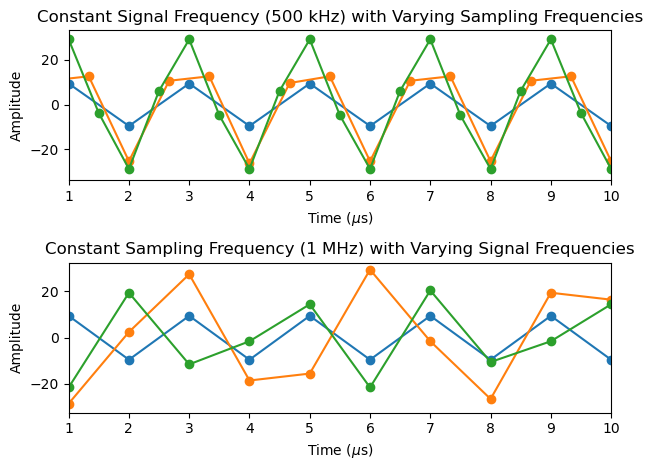

In [52]:
#data for signal frequency of 500 kHz, sampling frequency of 1MHz (Nyquist Limit)
data1 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_500kHz.npz")

#data for singal frequency 500kHz, sampling frequncy of 1MHz, 1.5MHz, and 2MHz
data2 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1.5MHz_500kHz.npz")
data3 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_2MHz_500kHz.npz")

#data for sampling frequency of 1.5MHz, signal frequency of 
data4 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
data5 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_400kHz.npz")

D = 2 #what sample set (1, 2, 3, 4, or 5)

signal1 = data1["arr_0"][D]
signal2 = data2["arr_0"][D]
signal3 = data3["arr_0"][D]
signal4 = data4["arr_0"][D]
signal5 = data5["arr_0"][D]

signal1 = signal1 - np.mean(signal1)
signal2 = signal2 - np.mean(signal2)
signal3 = signal3 - np.mean(signal3)
signal4 = signal4 - np.mean(signal4)
signal5 = signal5 - np.mean(signal5)

time1 = np.arange(len(signal1)) / 1e6
time2 = np.arange(len(signal2)) / 1.5e6
time3 = np.arange(len(signal3)) / 2e6
time4 = np.arange(len(signal4)) / 1e6
time5 = np.arange(len(signal5)) / 1e6

plt.subplot(2,1,1)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time2 * 1e6, signal2, marker="o")
plt.plot(time3 * 1e6, signal3, marker="o")
plt.xlim(1, 10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Signal Frequency (500 kHz) with Varying Sampling Frequencies")

plt.subplot(2,1,2)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time4 * 1e6, signal4, marker="o")
plt.plot(time5 * 1e6, signal5, marker="o")
plt.xlim(1,10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Sampling Frequency (1 MHz) with Varying Signal Frequencies")
plt.tight_layout()
plt.show()

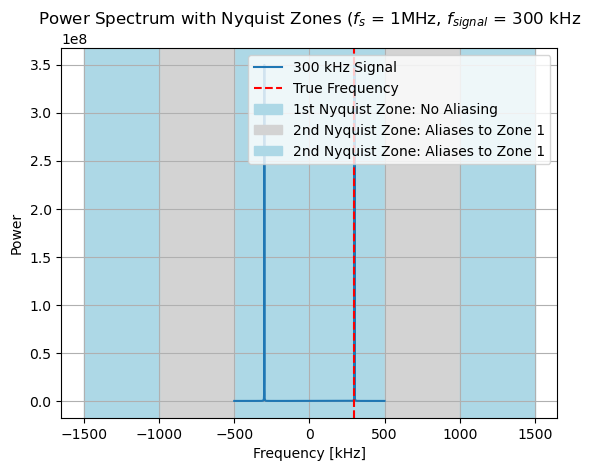

In [ ]:
#Attempt to show first Nyquist Zone for signal 1, using 1MHz, 300kHz data (data4)
fs = 1e6 #Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 #Signal frequency (Hz)

spectrum = np.fft.fft(signal4)
freq = np.fft.fftfreq(len(signal4), d=1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

plt.plot(freqs_shift/1e3, power, label="300 kHz Signal")
plt.axvline(true_freq/1e3, color="red", linestyle="--", label="True Frequency")

#Showing Nyquist Zones
for zone in range(1, 4):
    boundaries = zone * nyquist_freq
    color = "lightblue" if zone % 2 == 1 else "lightgray"
    if zone == 1:
        label = "1st Nyquist Zone: No Aliasing"
    elif zone == 2:
        label = "2nd Nyquist Zone: Aliases to Zone 1"

    plt.axvspan((zone - 1) * nyquist_freq/1e3, zone * nyquist_freq/1e3, color=color, label=label)
    plt.axvspan(-zone * nyquist_freq/1e3, -(zone - 1) * nyquist_freq/1e3, color=color)

plt.xlabel("Frequency [kHz]")
plt.ylabel("Power")
plt.title("Power Spectrum with Nyquist Zones ($f_s$ = 1MHz, $f_{signal}$ = 300 kHz")
#plt.xlim(-1.5*nyquist_freq/1e3, 1.5*nyquist_freq/1e3)
plt.legend()
plt.grid()
plt.show()

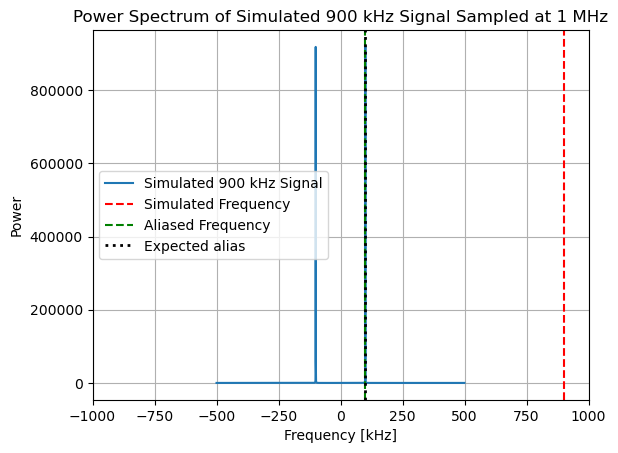

In [90]:
N = len(signal4)
time = np.arange(N) / fs
freq_sim1 = 900e3 #Simulated signal frequency (Hz)
signal_sim1 = np.cos(2*np.pi * freq_sim1 * time)

spectrum_sim1 = np.fft.fft(signal_sim1)
power_sim1 = np.abs(np.fft.fftshift(spectrum_sim1))**2

plt.plot(freqs_shift/1e3, power_sim1, label="Simulated 900 kHz Signal")
plt.axvline(freq_sim1/1e3, color="red", linestyle="--", label="Simulated Frequency")
plt.axvline((fs - freq_sim1)/1e3, color="green", linestyle="--", label="Aliased Frequency")

expected_alias = fs - freq_sim1  # 300 kHz
plt.axvline(expected_alias/1e3, color='black', linestyle=':', linewidth=2, label='Expected alias')

plt.xlabel("Frequency [kHz]")
plt.ylabel("Power")
plt.title("Power Spectrum of Simulated 900 kHz Signal Sampled at 1 MHz")
plt.xlim(-2*nyquist_freq/1e3, 2*nyquist_freq/1e3)
plt.legend()
plt.grid()
plt.show()



-500.0


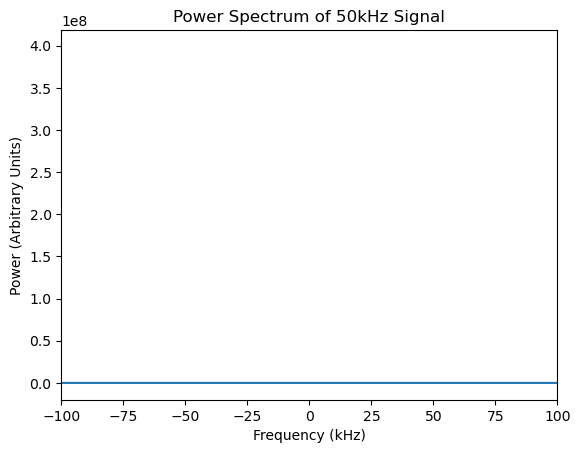

In [12]:
signal = data1["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(power))
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Power Spectrum of 50kHz Signal")
plt.show()



49.8046875


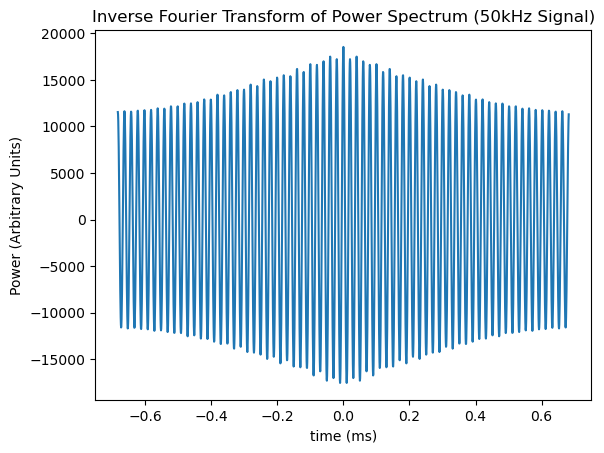

In [6]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
#N_padded = 5000
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs #Sampling period

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2
power_ifft = np.fft.ifft(power)

#N_padded = 5000
#pad_width = N_padded - N

time = np.arange(-N//2, N//2) * dt * 1000 #x-axis changed from seconds (s) to milliseconds (ms)
#padded_time = np.concatenate((time, np.zeros(pad_width)), dtype=complex)
# time = np.linspace(0, N*dt, N, endpoint=False)

#frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(time, np.fft.fftshift(power_ifft))
#plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("time (ms)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Inverse Fourier Transform of Power Spectrum (50kHz Signal)")
plt.show()

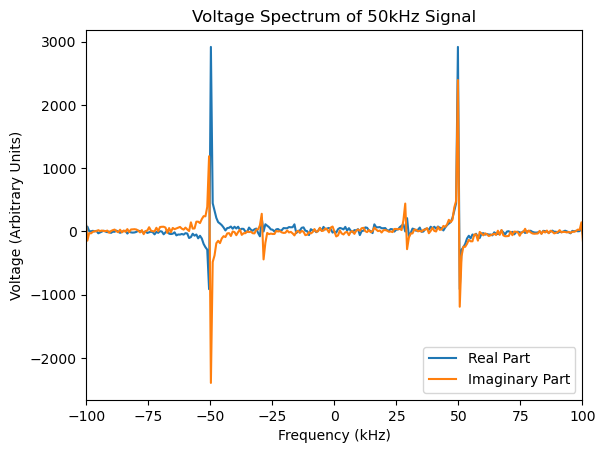

In [5]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
volt_real = np.real(fft_data)
volt_imag = np.imag(fft_data)

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_real), label="Real Part")
plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_imag), label="Imaginary Part")
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Voltage (Arbitrary Units)")
plt.title("Voltage Spectrum of 50kHz Signal")
plt.legend()
plt.show()